# Fetch Addresses — Nominatim Reverse Geocoding

Genera la dirección postal de cada una de las **247 zonas** del dataset ST-EVCDP usando la API **Nominatim de OpenStreetMap** (gratuita, sin API key).  

- Fuente: [nominatim.openstreetmap.org](https://nominatim.openstreetmap.org)
- Input: coordenadas `lon`/`la` de `information.csv`
- Output: `addresses_shenzhen.csv` con columnas `zone_id, lat, lon, address, district, suburb`
- Rate limit: **1 req/s** (política Nominatim) → ~4 min para 247 zonas
- Checkpointing: guarda progreso parcial cada 25 zonas

Replica **Table 1** del paper ChatEV: *Address = "No. 66 Gongchang Rd, Guangming Dt, Shenzhen, China"*

In [15]:
%pip install tqdm requests -q

import requests
import pandas as pd
import numpy as np
import time
import json
from pathlib import Path
from tqdm.notebook import tqdm

In [16]:
# ── CONFIGURA AQUÍ tu ruta a los datasets ────────────────────────────
# None = auto-descubrir en Drive (Colab/extensión Colab)
# Si falla, pon la ruta manualmente: "/content/drive/MyDrive/tu_carpeta"
DATASETS_PATH_OVERRIDE = None

import os, glob

if DATASETS_PATH_OVERRIDE:
    DATASETS_PATH = DATASETS_PATH_OVERRIDE
    print(f"Usando ruta manual: {DATASETS_PATH}")
else:
    candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
    if candidates:
        DATASETS_PATH = os.path.dirname(candidates[0])
        print(f"Encontrado automáticamente: {DATASETS_PATH}")
    else:
        try:
            from google.colab import drive
            if not os.path.isdir("/content/drive/MyDrive"):
                drive.mount("/content/drive")
            candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
            if candidates:
                DATASETS_PATH = os.path.dirname(candidates[0])
                print(f"Encontrado tras montar Drive: {DATASETS_PATH}")
            else:
                print("ERROR: information.csv no encontrado en Drive.")
                print("Pon la ruta correcta en DATASETS_PATH_OVERRIDE arriba.")
                DATASETS_PATH = None
        except ImportError:
            print("No estás en Colab. Pon la ruta en DATASETS_PATH_OVERRIDE.")
            DATASETS_PATH = None

if DATASETS_PATH:
    test_file = f"{DATASETS_PATH}/information.csv"
    if os.path.exists(test_file):
        csvs = glob.glob(f"{DATASETS_PATH}/*.csv")
        print(f"OK — {len(csvs)} CSVs encontrados:")
        for c in sorted(csvs):
            print(f"  {os.path.basename(c)}")
    else:
        print(f"ERROR: {test_file} no existe. Revisa DATASETS_PATH_OVERRIDE.")

Encontrado automáticamente: /content/drive/MyDrive/datasets
OK — 11 CSVs encontrados:
  addresses_shenzhen.csv
  adj.csv
  calendar_features.csv
  distance.csv
  duration.csv
  information.csv
  occupancy.csv
  price.csv
  stations.csv
  time.csv
  volume.csv


In [17]:
# ── Rutas ─────────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    import os
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    IN_COLAB = True
    print("Drive montado.")
except ImportError:
    IN_COLAB = False
    # DATASETS_PATH se define en la celda de verificación de ruta
    if 'DATASETS_PATH' not in dir() or DATASETS_PATH is None:
        DATASETS_PATH = "./datasets"
    print("Local mode:", DATASETS_PATH)

CHECKPOINT_PATH = "addresses_checkpoint.json"
OUTPUT_PATH     = "addresses_shenzhen.csv"

# ── Cargar information.csv ────────────────────────────────────────────────
info = pd.read_csv(f"{DATASETS_PATH}/information.csv", index_col=0)
info.columns = [c.strip().lower().replace(" ", "_") for c in info.columns]

print(f"Zonas: {len(info)}")
print(f"Columnas: {list(info.columns)}")

# Identificar columnas lat/lon
LAT_COL = "la"   # latitud
LON_COL = "lon"  # longitud

# Verificar rango esperado (Shenzhen: lat 22.3–22.8, lon 113.7–114.5)
lats = info[LAT_COL].dropna()
lons = info[LON_COL].dropna()
print(f"\nLat range: {lats.min():.4f} – {lats.max():.4f}  (esperado ~22.3–22.8)")
print(f"Lon range: {lons.min():.4f} – {lons.max():.4f}  (esperado ~113.7–114.5)")

Drive montado.
Zonas: 247
Columnas: ['grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'cbd', 'dynamic_pricing']

Lat range: 22.4862 – 22.7899  (esperado ~22.3–22.8)
Lon range: 113.7904 – 114.5156  (esperado ~113.7–114.5)


In [18]:
HEADERS = {
    "User-Agent": "ChatEV-Academic-Research/1.0 (jimena.milla@cloudlevante.com)"
}

def reverse_geocode(lat: float, lon: float, retries: int = 3) -> dict:
    """Llama Nominatim reverse geocoding. Devuelve dict con address fields."""
    url = (
        f"https://nominatim.openstreetmap.org/reverse"
        f"?lat={lat}&lon={lon}&format=json&addressdetails=1"
    )
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            if resp.status_code == 429:
                time.sleep(5 * (attempt + 1))
                continue
            resp.raise_for_status()
            data = resp.json()
            addr = data.get("address", {})
            return {
                "display_name": data.get("display_name", ""),
                "road":         addr.get("road", addr.get("pedestrian", "N/A")),
                "suburb":       addr.get("suburb", addr.get("neighbourhood", "N/A")),
                "district":     addr.get("city_district", addr.get("county", "N/A")),
                "city":         addr.get("city", addr.get("town", "Shenzhen")),
                "postcode":     addr.get("postcode", "N/A"),
            }
        except Exception as e:
            if attempt == retries - 1:
                return {"display_name": "ERROR", "road": "N/A", "suburb": "N/A",
                        "district": "N/A", "city": "Shenzhen", "postcode": "N/A"}
            time.sleep(2)
    return {"display_name": "ERROR", "road": "N/A", "suburb": "N/A",
            "district": "N/A", "city": "Shenzhen", "postcode": "N/A"}


# Test con una zona
sample_lat = float(info[LAT_COL].iloc[0])
sample_lon = float(info[LON_COL].iloc[0])
print(f"Test zona 0: lat={sample_lat}, lon={sample_lon}")
result = reverse_geocode(sample_lat, sample_lon)
print(f"Resultado: {result}")

Test zona 0: lat=22.54041, lon=114.103
Resultado: {'display_name': '嘉宾路, 蔡屋围, 新围社区, 桂园街道, 罗湖区, 深圳市, 广东省, 518000, 中国', 'road': '嘉宾路', 'suburb': '桂园街道', 'district': 'N/A', 'city': '罗湖区', 'postcode': '518000'}


In [19]:
# ── Cargar checkpoint si existe ────────────────────────────────────────────
checkpoint = {}
if Path(CHECKPOINT_PATH).exists():
    with open(CHECKPOINT_PATH) as f:
        checkpoint = json.load(f)
    print(f"Checkpoint encontrado: {len(checkpoint)} zonas ya procesadas.")
else:
    print("Sin checkpoint previo — empezando desde zona 0.")

CHECKPOINT_EVERY = 25
SLEEP_BETWEEN   = 1.1  # segundos (política Nominatim: max 1 req/s)

# ── Iterar zonas ──────────────────────────────────────────────────────────
results = list(checkpoint.values()) if checkpoint else []
done_ids = set(checkpoint.keys())

zones_todo = [
    (i, row) for i, row in info.iterrows()
    if str(i) not in done_ids
]

print(f"Zonas restantes: {len(zones_todo)} / {len(info)}")

for zone_id, row in tqdm(zones_todo, desc="Reverse geocoding"):
    lat = row.get(LAT_COL, None)
    lon = row.get(LON_COL, None)

    if pd.isna(lat) or pd.isna(lon):
        entry = {"zone_id": zone_id, "lat": None, "lon": None,
                 "display_name": "N/A", "road": "N/A", "suburb": "N/A",
                 "district": "N/A", "city": "Shenzhen", "postcode": "N/A"}
    else:
        geocoded = reverse_geocode(float(lat), float(lon))
        entry = {"zone_id": zone_id, "lat": float(lat), "lon": float(lon), **geocoded}

    results.append(entry)
    checkpoint[str(zone_id)] = entry

    # Guardar checkpoint
    if len(results) % CHECKPOINT_EVERY == 0:
        with open(CHECKPOINT_PATH, "w") as f:
            json.dump(checkpoint, f)

    time.sleep(SLEEP_BETWEEN)

# Guardar checkpoint final
with open(CHECKPOINT_PATH, "w") as f:
    json.dump(checkpoint, f)

print(f"\nCompletado: {len(results)} zonas procesadas.")

Checkpoint encontrado: 247 zonas ya procesadas.
Zonas restantes: 0 / 247


Reverse geocoding: 0it [00:00, ?it/s]


Completado: 247 zonas procesadas.


In [20]:
# ── Guardar CSV ────────────────────────────────────────────────────────────
df_addr = pd.DataFrame(results).sort_values("zone_id").reset_index(drop=True)

# Columna address limpia para los prompts (road + district)
df_addr["address_short"] = df_addr.apply(
    lambda r: f"{r['road']}, {r['district']}, Shenzhen"
    if r["road"] != "N/A" else f"{r['district']}, Shenzhen",
    axis=1
)

df_addr.to_csv(OUTPUT_PATH, index=False)
print(f"Guardado: {OUTPUT_PATH}")
print(f"Shape:    {df_addr.shape}")
print(f"\nMuestra:")
print(df_addr[["zone_id", "lat", "lon", "address_short"]].head(5).to_string())

# Copiar a Drive si Colab
if IN_COLAB:
    import shutil
    dst = f"{DATASETS_PATH}/addresses_shenzhen.csv"
    shutil.copy(OUTPUT_PATH, dst)
    print(f"\nCopiado a Drive: {dst}")

Guardado: addresses_shenzhen.csv
Shape:    (247, 10)

Muestra:
   zone_id       lat       lon        address_short
0        1  22.54041  114.1030   嘉宾路, N/A, Shenzhen
1        3  22.55127  114.1208   翠园街, N/A, Shenzhen
2        5  22.54486  114.1304  沿河南路, N/A, Shenzhen
3        6  22.55403  114.1315   黄贝路, N/A, Shenzhen
4        7  22.56388  114.1430   三孔桥, N/A, Shenzhen

Copiado a Drive: /content/drive/MyDrive/datasets/addresses_shenzhen.csv


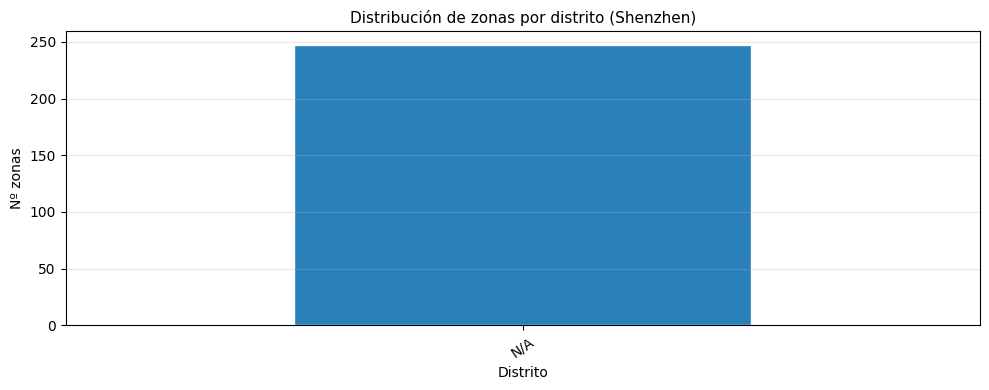


Ejemplo de address_short para 5 zonas:
  Zona 159: 观平路, N/A, Shenzhen
  Zona 272: 景行路, N/A, Shenzhen
  Zona 231: 宝丹路, N/A, Shenzhen
  Zona 200: 金碧路, N/A, Shenzhen
  Zona 311: N/A, Shenzhen


In [21]:
# ── Validación: distritos más frecuentes ──────────────────────────────────
import matplotlib.pyplot as plt

top_districts = df_addr["district"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
top_districts.plot(kind="bar", ax=ax, color="#2980B9", edgecolor="white")
ax.set_title("Distribución de zonas por distrito (Shenzhen)", fontsize=11)
ax.set_xlabel("Distrito")
ax.set_ylabel("Nº zonas")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("addresses_districts.png", dpi=130)
plt.show()

print("\nEjemplo de address_short para 5 zonas:")
for _, r in df_addr.sample(5).iterrows():
    print(f"  Zona {r['zone_id']:>3}: {r['address_short']}")